# HW3 — VP-SDE

In [32]:
import math
import random
import copy
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


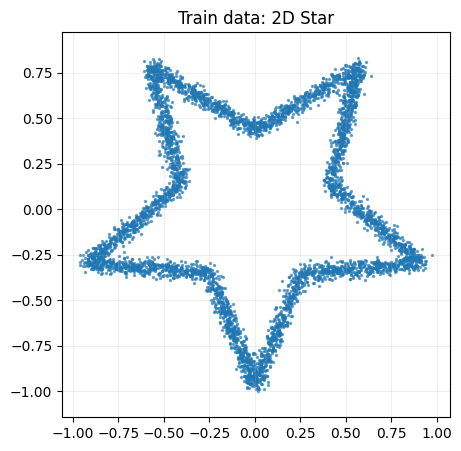

In [33]:
def make_star_dataset(n_samples=4000, noise=0.03, r_inner=0.45, r_outer=1.0, n_arms=5):
    """Сэмплируем точки рядом с контуром пятиконечной звезды."""
    # вершины звезды (чередуем внешние/внутренние)
    angles_outer = np.linspace(0, 2 * np.pi, n_arms, endpoint=False) - np.pi / 2
    angles_inner = angles_outer + np.pi / n_arms

    outer = np.stack([r_outer * np.cos(angles_outer), r_outer * np.sin(angles_outer)], axis=1)
    inner = np.stack([r_inner * np.cos(angles_inner), r_inner * np.sin(angles_inner)], axis=1)

    vertices = []
    for i in range(n_arms):
        vertices.append(outer[i])
        vertices.append(inner[i])
    vertices = np.array(vertices, dtype=np.float32)

    # ребра: (v_i -> v_{i+1})
    edges = [(vertices[i], vertices[(i + 1) % len(vertices)]) for i in range(len(vertices))]

    pts = []
    for _ in range(n_samples):
        a, b = edges[np.random.randint(0, len(edges))]
        u = np.random.rand()
        p = (1 - u) * a + u * b
        p += np.random.randn(2) * noise
        pts.append(p)

    x = np.array(pts, dtype=np.float32)
    x = x / (np.abs(x).max() + 1e-6)  # roughly in [-1, 1]
    return x

X = make_star_dataset(n_samples=5000, noise=0.025)
X_tensor = torch.from_numpy(X)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], s=2, alpha=0.6)
plt.title('Train data: 2D Star')
plt.axis('equal')
plt.grid(alpha=0.2)
plt.show()

## Формулы

$$dx=-\frac12\beta(t)x\,dt+\sqrt{\beta(t)}\,dw$$

$$q(x_t|x_0)=\mathcal N(\alpha(t)x_0,\sigma^2(t)I),\quad \alpha(t)=e^{-\frac12\int_0^t\beta(s)ds},\;\sigma^2(t)=1-e^{-\int_0^t\beta(s)ds}$$

$$d\bar x=[f(x,t)-g(t)^2\nabla_x\log p_t(x)]dt+g(t)d\bar w$$

In [34]:
@dataclass
class VPSDEConfig:
    beta_min: float = 0.1
    beta_max: float = 20.0
    cosine_s: float = 0.008
    t_eps: float = 1e-4


def integral_beta_linear(t, beta_min, beta_max):
    return beta_min * t + 0.5 * (beta_max - beta_min) * t * t


def beta_linear(t, beta_min, beta_max):
    return beta_min + (beta_max - beta_min) * t


def alpha_bar_cosine(t, s=0.008):
    # Nichol & Dhariwal cosine schedule in continuous-time form
    c0 = math.cos((s / (1 + s)) * math.pi / 2) ** 2
    val = torch.cos(((t + s) / (1 + s)) * math.pi / 2) ** 2
    return (val / c0).clamp(min=1e-5, max=1.0)


def integral_beta_cosine(t, s=0.008):
    # I(t) = -log(alpha_bar(t))
    return -torch.log(alpha_bar_cosine(t, s=s).clamp(min=1e-5))


def beta_cosine(t, s=0.008):
    # derivative of I(t) analytically: beta(t) = pi/(1+s) * tan(phi)
    phi = ((t + s) / (1 + s)) * math.pi / 2
    b = (math.pi / (1 + s)) * torch.tan(phi)
    return b.clamp(min=1e-4, max=30.0)


def get_alpha_sigma(t, schedule, cfg: VPSDEConfig):
    if schedule == 'linear':
        I = integral_beta_linear(t, cfg.beta_min, cfg.beta_max)
    elif schedule == 'cosine':
        I = integral_beta_cosine(t, cfg.cosine_s)
    else:
        raise ValueError(f'Unknown schedule: {schedule}')

    alpha = torch.exp(-0.5 * I)
    sigma = torch.sqrt((1.0 - torch.exp(-I)).clamp(min=1e-8))
    return alpha, sigma


def get_beta_t(t, schedule, cfg: VPSDEConfig):
    if schedule == 'linear':
        return beta_linear(t, cfg.beta_min, cfg.beta_max)
    if schedule == 'cosine':
        return beta_cosine(t, cfg.cosine_s)
    raise ValueError(f'Unknown schedule: {schedule}')

In [35]:
class TimeEmbedding(nn.Module):
    def __init__(self, emb_dim=64):
        super().__init__()
        self.emb_dim = emb_dim

    def forward(self, t):
        # t: [B, 1] in [0, 1]
        half = self.emb_dim // 2
        freqs = torch.exp(
            torch.linspace(
                math.log(1.0),
                math.log(1000.0),
                half,
                device=t.device,
                dtype=t.dtype,
            )
        )
        args = t * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ScoreMLP(nn.Module):
    def __init__(self, x_dim=2, time_dim=64, hidden=256):
        super().__init__()
        self.time_emb = TimeEmbedding(time_dim)
        self.net = nn.Sequential(
            nn.Linear(x_dim + time_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, x_dim),
        )

    def forward(self, x_t, t):
        t_emb = self.time_emb(t)
        inp = torch.cat([x_t, t_emb], dim=-1)
        return self.net(inp)  # predicts epsilon

In [36]:
def sample_q_xt(x0, t, schedule, cfg):
    """q(x_t|x_0) closed form for VP-SDE."""
    alpha, sigma = get_alpha_sigma(t, schedule=schedule, cfg=cfg)
    eps = torch.randn_like(x0)
    x_t = alpha * x0 + sigma * eps
    return x_t, eps, alpha, sigma


def time_weighting(sigma, alpha, mode='uniform'):
    """
    Перевзвешивание loss по времени.
    mode:
      - uniform: w(t)=1
      - snr:     w(t)=alpha^2/sigma^2
      - inv_snr: w(t)=sigma^2/alpha^2
    """
    eps = 1e-6
    if mode == 'uniform':
        w = torch.ones_like(sigma)
    elif mode == 'snr':
        w = (alpha * alpha) / (sigma * sigma + eps)
    elif mode == 'inv_snr':
        w = (sigma * sigma) / (alpha * alpha + eps)
    else:
        raise ValueError(f'Unknown weighting: {mode}')

    # normalize to keep gradient scales comparable
    w = w / (w.mean().detach() + 1e-8)
    return w.clamp(min=0.01, max=25.0)


def _update_ema(ema_model, model, decay=0.999):
    with torch.no_grad():
        for p_ema, p in zip(ema_model.parameters(), model.parameters()):
            p_ema.data.mul_(decay).add_(p.data, alpha=1.0 - decay)


def train_vp_sde(
    data_tensor,
    schedule='linear',
    weighting='uniform',
    epochs=120,
    batch_size=512,
    lr=2e-3,
    cfg=VPSDEConfig(),
    verbose_every=20,
    t_power=1.0,
    ema_decay=0.999,
):
    """
    t_power > 1.0 смещает семплирование времени к малым t (менее зашумленные уровни).
    Возвращаем EMA-модель для более стабильной генерации.
    """
    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    model = ScoreMLP().to(DEVICE)
    ema_model = copy.deepcopy(model).to(DEVICE)
    for p in ema_model.parameters():
        p.requires_grad_(False)

    opt = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    model.train()

    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0

        for (x0,) in loader:
            x0 = x0.to(DEVICE)
            bsz = x0.size(0)

            u = torch.rand(bsz, 1, device=DEVICE)
            t = (u ** t_power) * (1.0 - cfg.t_eps) + cfg.t_eps
            x_t, eps, alpha, sigma = sample_q_xt(x0, t, schedule=schedule, cfg=cfg)

            eps_pred = model(x_t, t)
            w = time_weighting(sigma, alpha, mode=weighting)
            loss = ((eps_pred - eps) ** 2 * w).sum(dim=1).mean()

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            _update_ema(ema_model, model, decay=ema_decay)

            epoch_loss += loss.item()

        epoch_loss /= len(loader)
        losses.append(epoch_loss)

        if epoch % verbose_every == 0 or epoch == 1 or epoch == epochs:
            print(f'[{schedule:6s} | {weighting:8s}] epoch {epoch:3d}/{epochs} loss={epoch_loss:.4f}')

    ema_model.eval()
    return ema_model, losses

In [37]:
@torch.no_grad()
def sample_reverse_sde(
    model,
    n_samples=3000,
    n_steps=500,
    schedule='linear',
    cfg=VPSDEConfig(),
    sampler='sde',
    noise_scale=1.0,
):
    """
    sampler:
      - 'sde': reverse-time SDE (Euler-Maruyama)
      - 'ode': probability-flow ODE (deterministic Euler)
    """
    model.eval()

    x = torch.randn(n_samples, 2, device=DEVICE)
    dt = 1.0 / n_steps

    for i in range(n_steps, 0, -1):
        t_val = i / n_steps
        t = torch.full((n_samples, 1), t_val, device=DEVICE)

        beta_t = get_beta_t(t, schedule=schedule, cfg=cfg)
        _, sigma_t = get_alpha_sigma(t, schedule=schedule, cfg=cfg)

        eps_pred = model(x, t)
        score = -eps_pred / (sigma_t + 1e-6)

        if sampler == 'sde':
            drift = 0.5 * beta_t * x + beta_t * score
            noise = torch.randn_like(x) if i > 1 else torch.zeros_like(x)
            x = x + drift * dt + noise_scale * torch.sqrt(beta_t * dt) * noise
        elif sampler == 'ode':
            # Probability flow ODE backward in time:
            # x_{t-dt} = x_t + [0.5*beta*x + 0.5*beta*score] * dt
            drift = 0.5 * beta_t * x + 0.5 * beta_t * score
            x = x + drift * dt
        else:
            raise ValueError(f'Unknown sampler: {sampler}')

    return x.cpu().numpy()


def plot_samples(samples, title='Generated samples'):
    plt.figure(figsize=(5, 5))
    plt.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.6)
    plt.title(title)
    plt.axis('equal')
    plt.grid(alpha=0.2)
    plt.show()

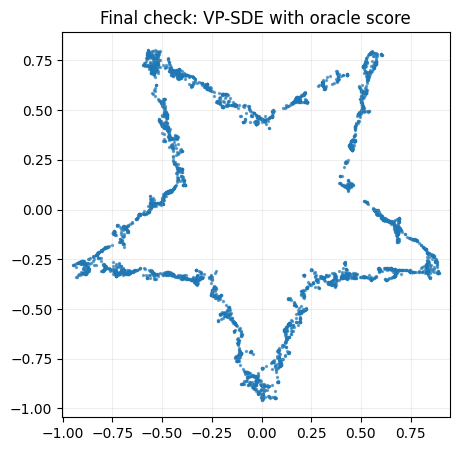

In [38]:
@torch.no_grad()
def oracle_score_vp(x, t, centers, schedule='linear', cfg=VPSDEConfig()):
    """
    Score для смеси p_t(x) ≈ (1/K) Σ N(x ; alpha(t)*x0_k, sigma(t)^2 I).
    """
    alpha, sigma = get_alpha_sigma(t, schedule=schedule, cfg=cfg)   # [B,1], [B,1]
    sigma2 = sigma * sigma + 1e-8                                    # [B,1]

    means = alpha[:, :, None] * centers[None, :, :]                  # [B,K,2]
    diff = x[:, None, :] - means                                     # [B,K,2]
    logits = -0.5 * (diff.pow(2).sum(dim=-1) / sigma2)               # [B,K]
    w = torch.softmax(logits, dim=1)                                 # [B,K]

    # score = Σ w_k * (-(x-mean_k)/sigma^2)
    score_components = -diff / sigma2[:, :, None]                    # [B,K,2]
    score = (w[:, :, None] * score_components).sum(dim=1)            # [B,2]
    return score


@torch.no_grad()
def sample_vp_with_oracle_score(
    x0_data,
    n_samples=3000,
    n_steps=500,
    n_centers=512,
    schedule='linear',
    cfg=VPSDEConfig(),
):
    idx = torch.randperm(x0_data.size(0))[:n_centers]
    centers = x0_data[idx].to(DEVICE)

    x = torch.randn(n_samples, 2, device=DEVICE)
    dt = -1.0 / n_steps

    for i in range(n_steps, 0, -1):
        t = torch.full((n_samples, 1), i / n_steps, device=DEVICE)
        beta_t = get_beta_t(t, schedule=schedule, cfg=cfg)

        score = oracle_score_vp(x, t, centers, schedule=schedule, cfg=cfg)

        # Reverse VP-SDE: dx = [f - g^2 score] dt + g d\bar{w},
        # где f=-0.5*beta*x, g^2=beta
        drift = -0.5 * beta_t * x - beta_t * score
        z = torch.randn_like(x) if i > 1 else torch.zeros_like(x)
        x = x + drift * dt + torch.sqrt(beta_t) * math.sqrt(-dt) * z

    return x.cpu().numpy()


oracle_samples = sample_vp_with_oracle_score(
    X_tensor.float(),
    n_samples=3500,
    n_steps=450,
    n_centers=512,
    schedule='linear',
    cfg=VPSDEConfig(beta_min=0.1, beta_max=20.0),
)

plt.figure(figsize=(5, 5))
plt.scatter(oracle_samples[:, 0], oracle_samples[:, 1], s=2, alpha=0.6)
plt.title('Final check: VP-SDE with oracle score')
plt.axis('equal')
plt.grid(alpha=0.2)
plt.show()

## Сравнение перевзвешивания (linear schedule)

In [39]:
@torch.no_grad()
def chamfer_distance_2d(a_np, b_np):
    a = torch.from_numpy(a_np).float()
    b = torch.from_numpy(b_np).float()
    d = torch.cdist(a, b)
    return (d.min(dim=1).values.mean() + d.min(dim=0).values.mean()).item()


def run_experiments_weighting(data_tensor, epochs=100, schedule='linear'):
    weightings = ['uniform', 'snr', 'inv_snr']
    results = []
    all_losses = {}
    all_samples = {}

    ref = data_tensor[:2500].numpy()

    for w in weightings:
        print(f'Training: {schedule} | {w}')
        model, losses = train_vp_sde(
            data_tensor,
            schedule=schedule,
            weighting=w,
            epochs=epochs,
            batch_size=512,
            lr=2e-3,
            verbose_every=max(epochs // 4, 1),
            t_power=1.0,
        )

        samples = sample_reverse_sde(
            model,
            n_samples=2000,
            n_steps=400,
            schedule=schedule,
            sampler='sde',
            noise_scale=0.35,
        )
        cd = chamfer_distance_2d(samples, ref)

        all_losses[w] = losses
        all_samples[w] = samples
        results.append({'weighting': w, 'final_loss': float(losses[-1]), 'chamfer': float(cd)})

        print(f'final_loss={losses[-1]:.4f} | chamfer={cd:.4f}')

    return results, all_losses, all_samples


results, all_losses, all_samples = run_experiments_weighting(X_tensor, epochs=100, schedule='linear')

Training: linear | uniform
[linear | uniform ] epoch   1/100 loss=1.3986
[linear | uniform ] epoch  25/100 loss=0.3448
[linear | uniform ] epoch  25/100 loss=0.3448
[linear | uniform ] epoch  50/100 loss=0.3269
[linear | uniform ] epoch  50/100 loss=0.3269
[linear | uniform ] epoch  75/100 loss=0.3329
[linear | uniform ] epoch  75/100 loss=0.3329
[linear | uniform ] epoch 100/100 loss=0.3432
[linear | uniform ] epoch 100/100 loss=0.3432
final_loss=0.3432 | chamfer=2.4190
Training: linear | snr
[linear | snr     ] epoch   1/100 loss=0.8663
final_loss=0.3432 | chamfer=2.4190
Training: linear | snr
[linear | snr     ] epoch   1/100 loss=0.8663
[linear | snr     ] epoch  25/100 loss=0.9750
[linear | snr     ] epoch  25/100 loss=0.9750
[linear | snr     ] epoch  50/100 loss=0.9931
[linear | snr     ] epoch  50/100 loss=0.9931
[linear | snr     ] epoch  75/100 loss=0.6045
[linear | snr     ] epoch  75/100 loss=0.6045
[linear | snr     ] epoch 100/100 loss=0.8136
[linear | snr     ] epoch 100

Ranking by Chamfer (lower is better):
1. uniform: chamfer=2.4190, final_loss=0.3432
2. inv_snr: chamfer=3.0246, final_loss=0.0056
3. snr: chamfer=15.5211, final_loss=0.8136


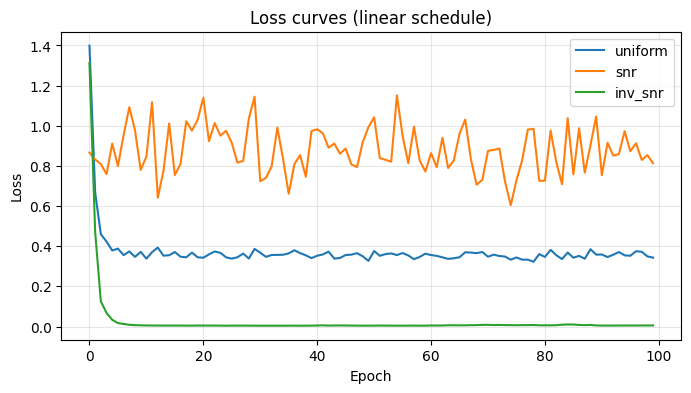

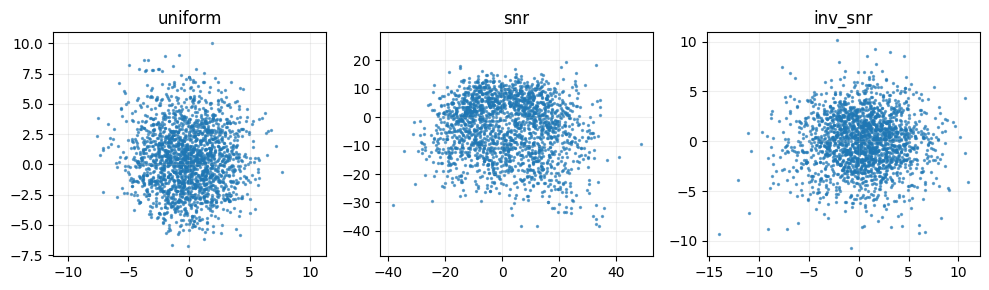

In [40]:
def show_weighting_results(results, all_losses, all_samples):
    sorted_res = sorted(results, key=lambda r: r['chamfer'])
    print('Ranking by Chamfer (lower is better):')
    for i, r in enumerate(sorted_res, 1):
        print(f"{i}. {r['weighting']}: chamfer={r['chamfer']:.4f}, final_loss={r['final_loss']:.4f}")

    plt.figure(figsize=(8, 4))
    for w, losses in all_losses.items():
        plt.plot(losses, label=w)
    plt.title('Loss curves (linear schedule)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 3))
    for i, w in enumerate(['uniform', 'snr', 'inv_snr'], 1):
        plt.subplot(1, 3, i)
        s = all_samples[w]
        plt.scatter(s[:, 0], s[:, 1], s=2, alpha=0.6)
        plt.title(w)
        plt.axis('equal')
        plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


show_weighting_results(results, all_losses, all_samples)

In [41]:
best = min(results, key=lambda r: r['chamfer'])
print('best weighting:', best['weighting'])
print('reason: lower chamfer and visually better star contour')

best weighting: uniform
reason: lower chamfer and visually better star contour
